In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Reduced Order Modeling on Stokes Equations</h3>
</div>

Imports:

In [2]:
from scipy.sparse.linalg import spsolve

from Utilities.Stokes_felib import *
from Utilities.Mesh_processing import *
from Utilities.Plot_functions import *

---

In [3]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/exchanger_device_altered_mesh_data.npz', num_of_refinements=3, 
                                                           plot=False,
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

In [14]:
def viscosity(x, y, subdomain):
    return np.where((x >= -2) & (x <= -1) &
                    (y >= 1/3) & (y <= 1),
                    10,
                    1000)

v_t = evalOnTrigs(p_fine, t_fine, viscosity)

In [37]:
import numpy as np

# ── 5 viscosity knobs ────────────────────────────────────────────────
_KNOTS = np.array([
    [-2.5,  0.0],
    [-1.0, -0.95],
    [ 0.0,  0.95],
    [ 1.0, -0.95],
    [ 2.5,  0.0],
])
_NU = np.array([10.0, 50.0, 20.0, 5.0, 100.0])


def viscosity_field(p, power: float = 2.0, eps: float = 1e-12):
    """
    Inverse-distance weighted viscosity at every node in p (N, 2).

    Each point gets a smooth blend of all 5 knot values, weighted by
    1 / dist^power.  This naturally produces:
      - radial iso-lines centered on each knot  (your sketch)
      - smooth transitions between knots
      - exact knot values if a node lands on a knot

    power=2  is the standard Shepard interpolation.
    Increase power (e.g. 4-6) for sharper, more localised influence zones.
    """
    # d[i, k] = distance from node i to knot k
    diff = p[:, None, :] - _KNOTS[None, :, :]    # (N, K, 2)
    d    = np.linalg.norm(diff, axis=2)          # (N, K)

    # Handle the rare case where a node sits exactly on a knot
    exact = d < eps                              # (N, K) bool
    hit   = exact.any(axis=1)                    # (N,)   bool

    w  = 1.0 / np.where(d < eps, eps, d) ** power   # (N, K)
    nu = (w * _NU[None, :]).sum(axis=1) / w.sum(axis=1)

    # Overwrite exact hits with the precise knot value
    if hit.any():
        knot_idx     = np.argmax(exact[hit], axis=1)
        nu[hit]      = _NU[knot_idx]

    return nu                                    # (N,)


def viscosity(x, y, subdomain=None, power: float = 2.0):
    """Scalar version — for single-point evaluation."""
    return float(viscosity_field(np.array([[x, y]]), power=power)[0])

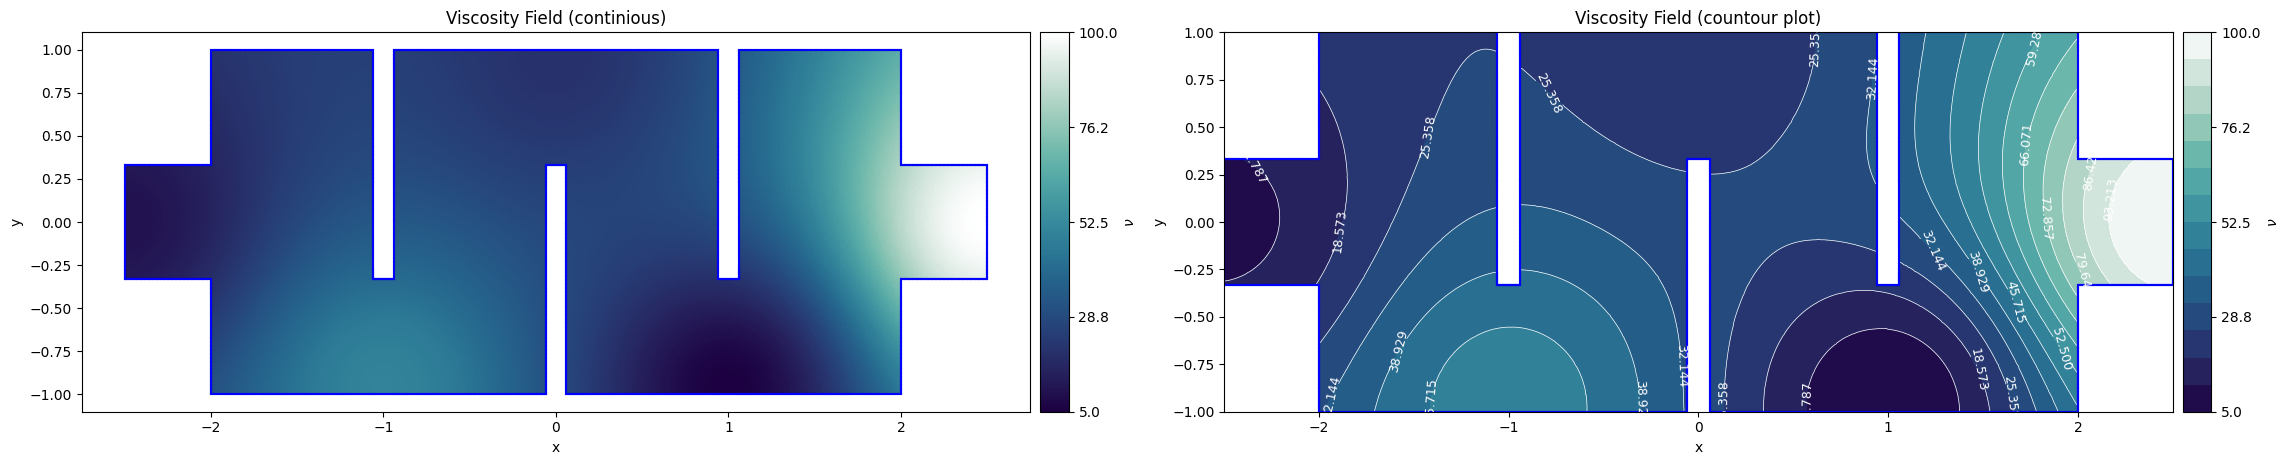

In [ ]:
v_t = evalOnTrigs(p_fine, t_fine, viscosity)

plot_viscosity(p_fine, t_fine, e_fine, v_t,
               n_levels=15,
               figsize=(23, 10),
               savetype='png')

In [26]:
import numpy as np
import plotly.graph_objects as go

def plot_viscosity_3d(
    p,
    t,
    nu_T,
    z_scale=1.0,
    title="Viscosity Field"
):

    triangles = t[:, :3]

    Nv = p.shape[0]

    nu_nodes = np.zeros(Nv)
    counts = np.zeros(Nv)

    for k, tri_nodes in enumerate(triangles):
        nu_nodes[tri_nodes] += nu_T[k]
        counts[tri_nodes] += 1

    nu_nodes /= np.maximum(counts, 1)

    fig = go.Figure(
        data=[
            go.Mesh3d(
                x=p[:,0],
                y=p[:,1],
                z=z_scale * nu_nodes,
                i=triangles[:,0],
                j=triangles[:,1],
                k=triangles[:,2],
                intensity=nu_nodes,
                colorscale="Viridis",
                showscale=True,
                colorbar=dict(title="ν")
            )
        ]
    )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="x",
            yaxis_title="y",
            zaxis_title="ν"
        ),
        width=1200,
        height=900
    )

    fig.show()

In [27]:
plot_viscosity_3d(
    p_fine,
    t_fine,
    v_t,
    z_scale=5
)

---

In [9]:

def compute_U_P_solution(p_fine, t_fine, e_fine, p_coarse, t_coarse,
                         inlet_velocity: float = 1.0,
                         kinematic_viscosity: float = 0.01):

    Nv = p_fine.shape[0]
    Np = p_coarse.shape[0]
    eps = 1e-10   

    xmin = p_fine[:, 0].min()
    xmax = p_fine[:, 0].max()

    inlet_idx  = np.where(np.abs(p_fine[:, 0] - xmin) < eps)[0]
    outlet_idx = np.where(np.abs(p_fine[:, 0] - xmax) < eps)[0]

    boundary_nodes = np.unique(e_fine[e_fine[:, 2] > 0, 0:2])
    v_wall_idx = np.setdiff1d(boundary_nodes, np.concatenate([inlet_idx, outlet_idx]))
    dirichlet_nodes = np.unique(np.concatenate([inlet_idx, v_wall_idx]))

    lf_x = np.zeros(Nv)
    lf_y = np.zeros(Nv)
    lf_x[inlet_idx] = inlet_velocity          

    A  = calculate_velocity_A(p_fine, t_fine, kinematic_viscosity)
    Bx, By = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
    K  = calculate_Saddle_point_K(A, Bx, By)

    F = np.zeros(2 * Nv + Np)
    F[:Nv]    -= A.dot(lf_x)
    F[2*Nv:]  -= Bx.dot(lf_x)  

    print(f"K is of the shape {K.shape}")

    K = K.tolil()

    for i in dirichlet_nodes:
        K[i, :]  = 0.0
        K[i, i]  = 1.0
        F[i]     = 0.0

        iy = i + Nv
        K[iy, :] = 0.0
        K[iy, iy] = 1.0
        F[iy]    = 0.0

    is_outlet_p = np.abs(p_coarse[:, 0] - xmax) < eps
    p_ref_idx   = np.where(is_outlet_p)[0]

    if len(p_ref_idx) == 0:
        p_ref_idx = [np.argmin(np.abs(p_coarse[:, 0] - xmax))]
        print("Warning: no coarse node exactly on outlet x; using nearest.")

    p_row = 2 * Nv + p_ref_idx[0]
    K[p_row, :] = 0.0
    K[p_row, p_row] = 1.0
    F[p_row] = 0.0        

    # ------------------------------------------------------------------
    # Solve
    # ------------------------------------------------------------------
    print("Solving lifted system...")
    sol = spsolve(K.tocsc(), F)

    if np.any(np.isnan(sol)):
        raise RuntimeError("NaNs in solution — check mesh connectivity and BCs.")

    u0_x     = sol[:Nv]
    u0_y     = sol[Nv:2*Nv]
    pressure = sol[2*Nv:]

    # Recover full velocity
    ux = u0_x + lf_x
    uy = u0_y + lf_y

    # ------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------
    div = Bx @ ux + By @ uy
    print(f"||div u|| = {np.linalg.norm(div):.3e}")
    print(f"max |div| = {np.max(np.abs(div)):.3e}")
    print(f"pressure  min/mean/max = "
          f"{pressure.min():.4f} / {pressure.mean():.4f} / {pressure.max():.4f}")

    return ux, uy, pressure


In [10]:
ux, uy, p_sol = compute_U_P_solution(p_fine, t_fine, e_fine, p_coarse, t_coarse, 1, v_t)

save_simulation_data(p_fine, e_fine, t_fine, 
                    p_coarse, e_coarse, t_coarse, 
                    ux, uy, p_sol,
                    name='Exchanger_device_with_varying_viscosity')

K is of the shape (218107, 218107)
Solving lifted system...
||div u|| = 3.337e-05
max |div| = 3.337e-05
pressure  min/mean/max = -3134.8578 / 10672.2916 / 28093.4029
Simulation 'Exchanger_device_with_varying_viscosity' data saved.


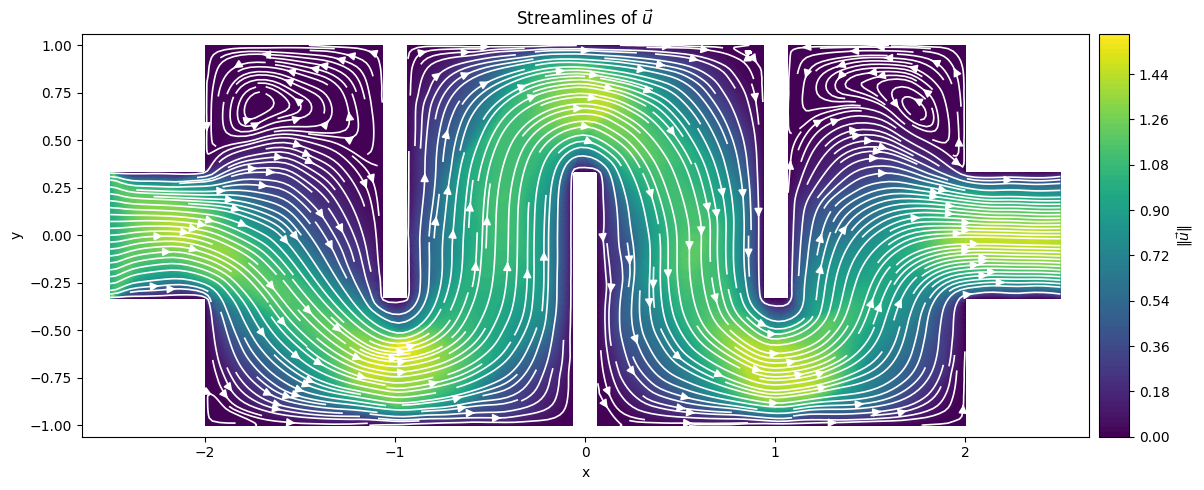

In [11]:
plot_streamlines(p_fine, t_fine, ux, uy,
                 grid_num=(500,500),
                 figsize=(15,5),
                 density=3.7)

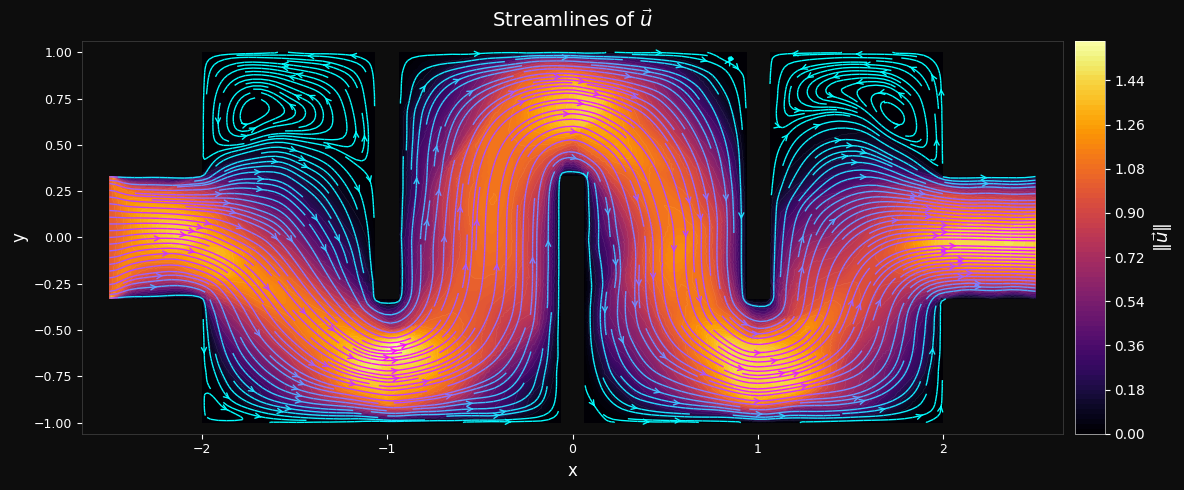

In [12]:
plot_streamlines_experimental(p_fine, t_fine, ux, uy,
                              grid_num=(500,500),
                              figsize=(15,5),
                              density=3.7)

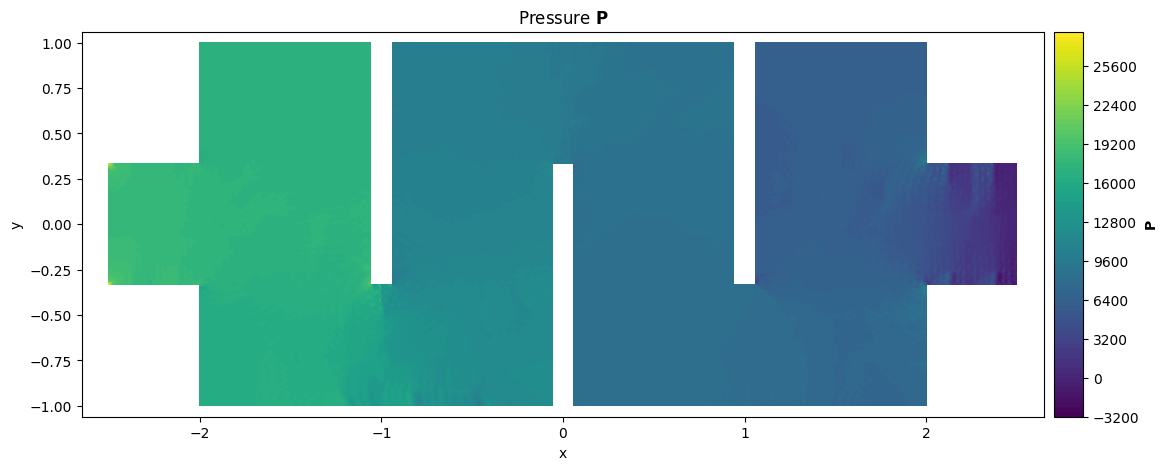

In [13]:
plot_pressure(p_coarse, t_coarse, p_sol,
              figsize=(15,5))

---
### Experimenting with Curl